In [1]:
!rm -rf sample_data

In [2]:
import torch
from torch import nn
import matplotlib.pyplot as plt
import numpy as np

In [3]:
try:
  import mlflow
except:
  !pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 101.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 86.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 54.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 49.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.2/216.2 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.9/123.9 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132

In [4]:
try:
  import torchvision
except:
  !pip install torchvision

In [5]:
import torchvision
from torchvision import datasets
from torchvision import models
from torch.utils.data import DataLoader
from torchvision import transforms

print(f"Pytorch version: {torch.__version__}\ntorchvision version:{torchvision.__version__}")


Pytorch version: 2.11.0+cpu
torchvision version:0.26.0+cpu


In [6]:
try:
  import torchinfo
except:
  !pip install torchinfo

In [7]:
# Modular imports
from data_setup import create_datasets, get_data
from engine import train
from model import VGGMini
from utils import (save_model, load_model, display_random_images_from_dataset,
                   set_seed, pred_and_plot_image, plot_loss_acc_curves,
                   plot_random_images_from_path, get_device,
                   walk_through_dir)

In [8]:
device = get_device()
device

'cpu'

In [9]:
!pwd

/content


In [10]:
get_data()

Did not find /content/data/pizza_steak_sushi directory, creating one...
Unzipping pizza, steak, sushi data...


In [11]:
!rm -Rf sample_data/

In [12]:
from pathlib import Path
import os

train_dir = Path('/content/data/pizza_steak_sushi/train')
test_dir = Path('/content/data/pizza_steak_sushi/test')

train_transformations = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(degrees=90)
])

test_transformations = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor()

])

NUM_WORKERS = os.cpu_count()

BATCH_SIZE = 32

train_dataloader, test_dataloader, class_names, class_to_idx = create_datasets(train_dir = train_dir,
                                                                               test_dir = test_dir,
                                                                               train_transformations = train_transformations,
                                                                               test_transformations=test_transformations,
                                                                               NUM_WORKERS = NUM_WORKERS,
                                                                               BATCH_SIZE = BATCH_SIZE)

In [13]:
class_names, class_to_idx

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

In [14]:
len(next(iter(train_dataloader))[0]), len(next(iter(test_dataloader))[0])
# number of images inside a single batch, will be different for the last batch

(32, 32)

In [15]:
len(next(iter(train_dataloader))[1]), len(next(iter(test_dataloader))[1])
# number of labels inside a single batch, will be different for the last batch

(32, 32)

In [16]:
train_batch = next(iter(train_dataloader))
train_batch[0][0].ndim,train_batch[0][0].shape

(3, torch.Size([3, 64, 64]))

In [17]:
input_channels = 3
hidden_channels = 10
output_shape = len(class_names)
model = VGGMini(input_channels = input_channels,
                hidden_channels = hidden_channels,
                output_shape = output_shape)

In [18]:
model

VGGMini(
  (block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2560, out_features=3, bias=True)
  )
)

In [19]:
from torchinfo import summary
# take channels into account
summary(model,[1,3,64,64],col_names=["input_size","output_size","num_params","trainable"])

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
VGGMini                                  [1, 3, 64, 64]            [1, 3]                    --                        True
├─Sequential: 1-1                        [1, 3, 64, 64]            [1, 10, 32, 32]           --                        True
│    └─Conv2d: 2-1                       [1, 3, 64, 64]            [1, 10, 64, 64]           280                       True
│    └─ReLU: 2-2                         [1, 10, 64, 64]           [1, 10, 64, 64]           --                        --
│    └─Conv2d: 2-3                       [1, 10, 64, 64]           [1, 10, 64, 64]           910                       True
│    └─ReLU: 2-4                         [1, 10, 64, 64]           [1, 10, 64, 64]           --                        --
│    └─MaxPool2d: 2-5                    [1, 10, 64, 64]           [1, 10, 32, 32]           --                        --
├─Sequent

In [20]:
# our model is currently only of 0.91 MB of size

In [21]:
walk_through_dir(train_dir)

there are 3 directories and 0 images in inside /content/data/pizza_steak_sushi/train directory
there are 0 directories and 72 images in inside /content/data/pizza_steak_sushi/train/sushi directory
there are 0 directories and 75 images in inside /content/data/pizza_steak_sushi/train/steak directory
there are 0 directories and 78 images in inside /content/data/pizza_steak_sushi/train/pizza directory


In [22]:
walk_through_dir(test_dir)

there are 3 directories and 0 images in inside /content/data/pizza_steak_sushi/test directory
there are 0 directories and 31 images in inside /content/data/pizza_steak_sushi/test/sushi directory
there are 0 directories and 19 images in inside /content/data/pizza_steak_sushi/test/steak directory
there are 0 directories and 25 images in inside /content/data/pizza_steak_sushi/test/pizza directory


total images: 300


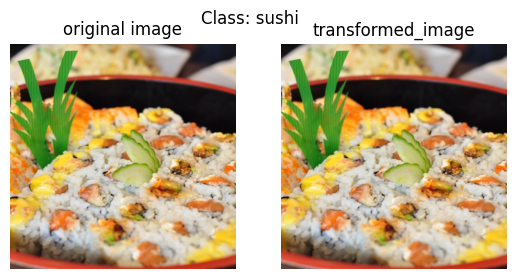

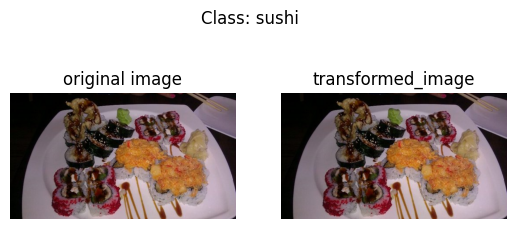

In [23]:
import glob
data_path = '/content/data/pizza_steak_sushi'
all_image_paths = list(Path(data_path).glob('*/*/*.jpg'))
print('total images:',len(all_image_paths))

plot_random_images_from_path(image_paths=all_image_paths,
                             transform=transforms.Compose([transforms.ToTensor(),
                                                           transforms.RandomHorizontalFlip(p=0.5)]),
                             n=2,
                             seed=42)

# NOTE: random horizontal flip = can or can't be flip

In [24]:

# basic baseline run
from tqdm.auto import tqdm
NUM_EPOCHS = 10
optimizer = torch.optim.Adam(params = model.parameters(),
                             lr=0.00001)
loss_fn = torch.nn.CrossEntropyLoss()

results = train(model = model,
                train_dataloader=train_dataloader,
                test_dataloader=test_dataloader,
                optimizer=optimizer,
                device = device,
                loss_fn=loss_fn,
                epochs=NUM_EPOCHS,
                )

  0%|          | 0/10 [00:00<?, ?it/s]

Completed 1 batch out of 8 for training
Completed 2 batch out of 8 for training
Completed 3 batch out of 8 for training
Completed 4 batch out of 8 for training
Completed 5 batch out of 8 for training
Completed 6 batch out of 8 for training
Completed 7 batch out of 8 for training
Completed 8 batch out of 8 for training
Completed 1 batch out of 3 for testing
Completed 2 batch out of 3 for testing
Completed 3 batch out of 3 for testing
Epoch: 1 | train_loss: 1.1013 | train_acc: 0.3333 | test_loss: 1.1064 | test_acc: 0.1979
Completed 1 batch out of 8 for training
Completed 2 batch out of 8 for training
Completed 3 batch out of 8 for training
Completed 4 batch out of 8 for training
Completed 5 batch out of 8 for training
Completed 6 batch out of 8 for training
Completed 7 batch out of 8 for training
Completed 8 batch out of 8 for training
Completed 1 batch out of 3 for testing
Completed 2 batch out of 3 for testing
Completed 3 batch out of 3 for testing
Epoch: 2 | train_loss: 1.0944 | train

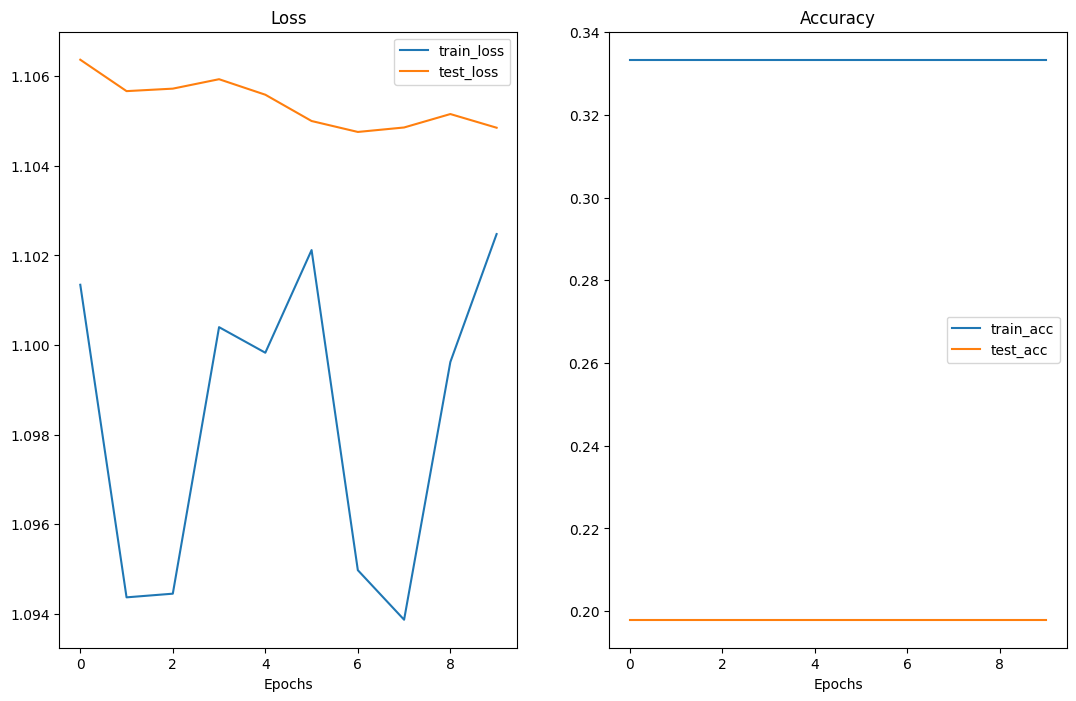

In [25]:
plot_loss_acc_curves(results)

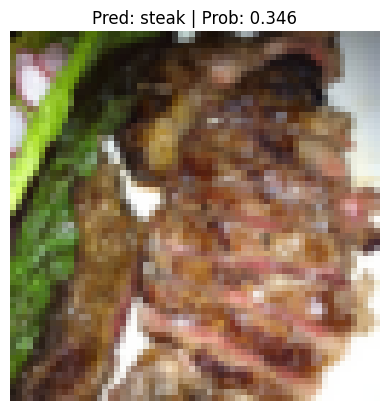

In [26]:
pred_image_path_sushi = '/content/data/pizza_steak_sushi/test/steak/1016217.jpg'
pred_and_plot_image(model=model,
                    image_path = pred_image_path_sushi,
                    class_names= class_names,
                    transform = transforms.Compose([transforms.Resize((64,64))]))
# or we could directly write transform = test_transformations
# resize, to tensor and other stuff

In [27]:
from datetime import datetime
model_name = '5_epochs_'+ datetime.now().strftime('%Y_Y_%m_m_%d_d_%H:%M:%S')+'_VGG16MINI.pth'
save_model(model=model,
           target_dir='/content/models',
           model_name=model_name)

[INFO] Saving model to: /content/models/5_epochs_2026_Y_08_m_20_d_15:49:53_VGG16MINI.pth


In [28]:
input_channels = 3
hidden_channels = 10
output_shape = len(class_names)

target_file = '/content/models/'+ model_name

loaded_model_skeleton = VGGMini(input_channels = input_channels,
                hidden_channels = hidden_channels,
                output_shape = output_shape)

loaded_model = load_model(model = loaded_model_skeleton,
                   target_file = target_file)

In [29]:
loaded_model.eval()

VGGMini(
  (block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2560, out_features=3, bias=True)
  )
)

In [30]:
summary(loaded_model,[1,3,64,64],col_names=["input_size","output_size","num_params","trainable"])

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
VGGMini                                  [1, 3, 64, 64]            [1, 3]                    --                        True
├─Sequential: 1-1                        [1, 3, 64, 64]            [1, 10, 32, 32]           --                        True
│    └─Conv2d: 2-1                       [1, 3, 64, 64]            [1, 10, 64, 64]           280                       True
│    └─ReLU: 2-2                         [1, 10, 64, 64]           [1, 10, 64, 64]           --                        --
│    └─Conv2d: 2-3                       [1, 10, 64, 64]           [1, 10, 64, 64]           910                       True
│    └─ReLU: 2-4                         [1, 10, 64, 64]           [1, 10, 64, 64]           --                        --
│    └─MaxPool2d: 2-5                    [1, 10, 64, 64]           [1, 10, 32, 32]           --                        --
├─Sequent

  0%|          | 0/3 [00:00<?, ?it/s]

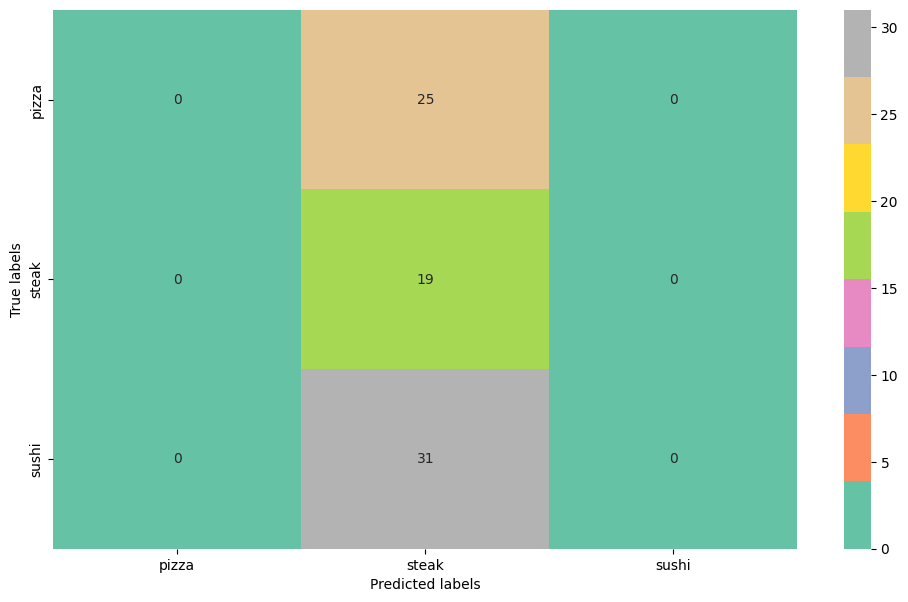

In [31]:
%matplotlib inline
from sklearn.metrics import confusion_matrix
import seaborn as sn
import pandas as pd

y_pred = []
y_true = []

# iterate over test data
for inputs, labels in tqdm(test_dataloader):
        loaded_model.to(device), inputs.to(device), labels.to(device)
        output = loaded_model(inputs) # Feed Network

        pred_logits = torch.softmax(output,dim=1)
        pred_labels = torch.argmax(pred_logits,dim=1).data.cpu().numpy()
        y_pred.extend(pred_labels) # Save Prediction

        labels = labels.data.cpu().numpy()
        y_true.extend(labels) # Save Truth

classes = class_names

cf_matrix = confusion_matrix(y_true, y_pred)
df_cm = pd.DataFrame(cf_matrix , index = [i for i in classes],
                     columns = [i for i in classes])
plt.figure(figsize = (12,7))
ax = sn.heatmap(df_cm, annot=True, cmap='Set2')
ax.set(xlabel='Predicted labels',ylabel='True labels')
plt.show()

### ViT implementation begins here:

In [32]:
training_resolution = 224

vit_preprocess_transformations = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((training_resolution,training_resolution))
])

In [33]:
vit_train_dataloader, vit_test_dataloader, vit_class_names, vit_class_to_idx = create_datasets(
                    train_dir = train_dir,
                    test_dir = test_dir,
                    train_transformations = vit_preprocess_transformations,
                    test_transformations= vit_preprocess_transformations,
                    NUM_WORKERS= os.cpu_count(),
                    BATCH_SIZE = 32)

In [34]:
vit_train_dataloader

In [35]:
vit_class_to_idx, vit_class_names

({'pizza': 0, 'steak': 1, 'sushi': 2}, ['pizza', 'steak', 'sushi'])

In [36]:
len(next(iter(vit_test_dataloader))[0]), len(next(iter(vit_train_dataloader))[0])

(32, 32)

Text(0.5, 1.0, 'sushi')

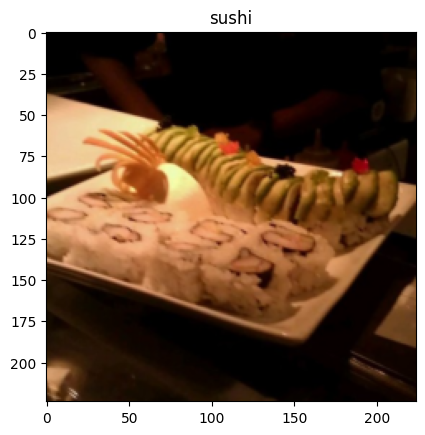

In [37]:
image_batch, label_batch = next(iter(vit_train_dataloader))

image, label = image_batch[0], label_batch[0]
plt.imshow(image.permute(1,2,0))
plt.title(vit_class_names[label])


In [38]:
image.ndim, image.shape, image.device

(3, torch.Size([3, 224, 224]), device(type='cpu'))

In [39]:
image

tensor([[[0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
          0.0000e+00, 0.0000e+00],
         [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
          0.0000e+00, 0.0000e+00],
         [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 1.4838e-03,
          1.4838e-03, 1.4838e-03],
         ...,
         [2.1688e-01, 2.5607e-01, 3.4786e-01,  ..., 9.4372e-02,
          1.0378e-01, 1.1358e-01],
         [1.8220e-01, 2.1214e-01, 2.6587e-01,  ..., 7.5111e-02,
          8.9467e-02, 9.7117e-02],
         [1.5981e-01, 1.8717e-01, 2.2979e-01,  ..., 6.9724e-02,
          8.1412e-02, 8.7989e-02]],

        [[0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 1.9205e-03,
          3.1154e-03, 3.1154e-03],
         [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 1.6305e-04,
          2.6450e-04, 2.6450e-04],
         [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
          0.0000e+00, 0.0000e+00],
         ...,
         [1.1492e-01, 1.4141e-01, 2.1066e-01,  ..., 2.7855e-02,
          3.661

In [40]:
patch_resolution = 16
# number of patches
num_patches = int(training_resolution * training_resolution) // (patch_resolution**2)
print(f"Number of patches: {num_patches}")

Number of patches: 196


In [41]:
print(f"image shape with dimensions as C,H,W: {image.shape}")

image shape with dimensions as C,H,W: torch.Size([3, 224, 224])


RuntimeError: permute(sparse_coo): number of dimensions in the tensor input does not match the length of the desired ordering of dimensions i.e. input.dim() = 4 is not equal to len(dims) = 3

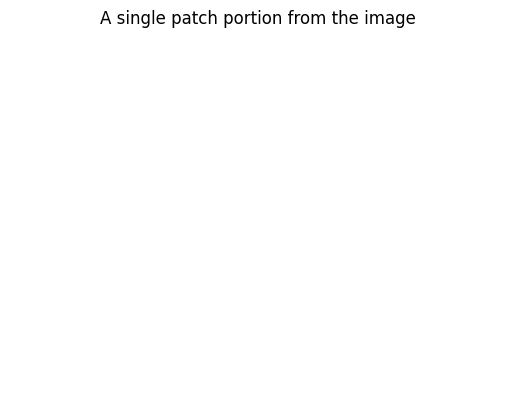

In [78]:
plt.axis(False)
plt.title("""A single patch portion from the image""")
plt.imshow(image.permute(1,2,0)[:patch_resolution,:patch_resolution,:])

In [43]:
# temp_image_unfold_test = image.unsqueeze(dim=0)
# unfold_layer = nn.Unfold(kernel_size=(patch_resolution,patch_resolution),stride = patch_resolution, dilation=1)
# a = unfold_layer(temp_image_unfold_test)
# a.shape

In [81]:
class PatchEmbeddings(nn.Module):

  def __init__(self,
               flattened_patch_size:int=768,
               hidden_dimension:int=768,
               patch_resolution:int=16):

    super().__init__()

    self.create_patches = nn.Unfold(kernel_size=(patch_resolution,patch_resolution),
                                                    stride=patch_resolution,
                                                    dilation=1)
  # torch.Size([1, 768, 196]) -> batchdim, number of pixels inside each flattened block, number of patches

    self.project_patches = nn.Linear(in_features=flattened_patch_size,
                                         out_features=hidden_dimension)

  def forward(self,x) -> torch.Tensor:
    assert x.shape[-1] % patch_resolution == 0, "Image_resolution should be a multiple of patch_resolution for even patches"
    x = self.create_patches(x)
    x = x.transpose(-2,-1)
    x = self.project_patches(x)
    return x
    # flatten -> linearly project

In [45]:
num_color_channels = image.shape[0]

In [46]:
image = image.unsqueeze(dim=0)

In [47]:
set_seed(42)

patch_embedding_projection_out_features = hidden_size = 768 # from table 1 ViT Base

patch_embedding_projection_in_features = (patch_resolution**2)*(num_color_channels) #P**2.C

single_patch_embedding = PatchEmbeddings(flattened_patch_size= patch_embedding_projection_in_features,
                                         hidden_dimension=patch_embedding_projection_out_features,
                                         patch_resolution = patch_resolution)

In [48]:
test_patch_image = single_patch_embedding(image)

In [49]:
test_patch_image.shape

torch.Size([1, 196, 768])

Text(0.5, 1.0, 'First 16 pixels from the first patch')

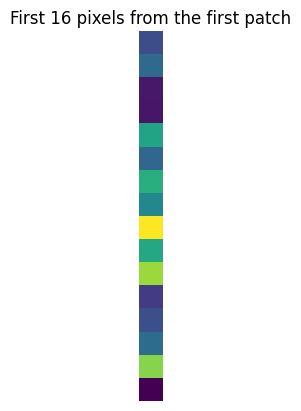

In [50]:
plt.imshow(test_patch_image.permute(1,2,0)[0,0:16,:].detach().numpy())
plt.axis(False)
plt.title("First 16 pixels from the first patch")

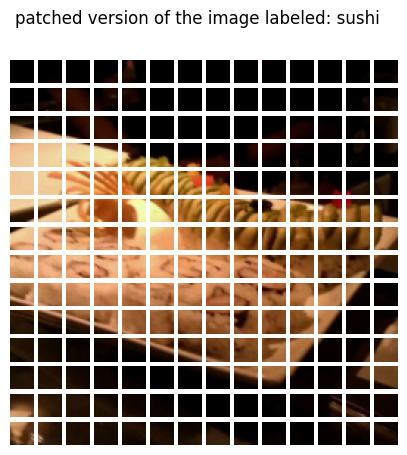

In [51]:
fig, ax = plt.subplots(14, 14, figsize=(5,5))
permute_image = image.squeeze(dim=0).permute(1,2,0)
for i in range(14):
  for j in range(14):
    ax[i,j].imshow(permute_image[(i * patch_resolution):((i+1)*patch_resolution),
                               (j * patch_resolution):((j+1)*patch_resolution),
                               :])
    ax[i,j].axis(False)
    plt.suptitle(f"patched version of the image labeled: {class_names[label]}")

In [52]:
summary(single_patch_embedding,[1,3,224,224])

Layer (type:depth-idx)                   Output Shape              Param #
PatchEmbeddings                          [1, 196, 768]             --
├─Unfold: 1-1                            [1, 768, 196]             --
├─Linear: 1-2                            [1, 196, 768]             590,592
Total params: 590,592
Trainable params: 590,592
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.59
Input size (MB): 0.60
Forward/backward pass size (MB): 1.20
Params size (MB): 2.36
Estimated Total Size (MB): 4.17

In [53]:
set_seed()
class_token = nn.Parameter(torch.randn(1,1,hidden_size),requires_grad=True)
# it should be batch_dimension in the first dim here but right now for debugging 1 also works
class_token.shape

torch.Size([1, 1, 768])

In [54]:
test_patch_image.shape

torch.Size([1, 196, 768])

In [55]:
q = test_patch_image
w = torch.cat((class_token,q),dim=1)
w.shape

torch.Size([1, 197, 768])

In [56]:
position_embeddings = nn.Parameter(torch.randn(1,num_patches+1,hidden_size),requires_grad=True)
position_embeddings.shape
# it should be 32 here but right now for debugging 1 also works

torch.Size([1, 197, 768])

In [57]:
position_and_patch_embeddings = w + position_embeddings #final input to be gone into the transformer model.
position_embeddings.shape

torch.Size([1, 197, 768])

In [76]:
# compute self-attention using your custom layer. use reshape and transpose to do it in a single matrix and combine it together later on.
# position_and_patch_embeddings.shape

In [59]:
# number of heads = 12 from table 1
# 197 = N
# 768 = D

In [75]:
# self_attention_layer = SelfAttention(hidden_size = 768, KQV_projection_dim = 768)
# r = self_attention_layer(position_and_patch_embeddings)
# r.shape

In [73]:
# # position_and_patch_embeddings
# msa_block = MultiHeadAttention(num_heads=12, embed_size=768)
# h = msa_block(position_and_patch_embeddings)

In [74]:
# position_and_patch_embeddings.shape

In [72]:
# summary(MultiHeadAttention(num_heads=12, embed_size=768),[[1, 197, 768]])

In [60]:
class SelfAttention(nn.Module):
  def __init__(self, hidden_size: int , KQV_projection_dim:int):
    super().__init__()

    self.key_projection = nn.Linear(in_features=hidden_size,
                                    out_features = KQV_projection_dim)

    self.query_projection = nn.Linear(in_features=hidden_size,
                                    out_features = KQV_projection_dim)

    self.value_projection = nn.Linear(in_features=hidden_size,
                                    out_features = KQV_projection_dim)

    self.key_query_projection_dim = KQV_projection_dim

  def forward(self,x) -> torch.Tensor:
      Q = self.query_projection(x)
      K = self.key_projection(x)
      V = self.value_projection(x) #NxDv
      K_t = K.transpose(-2,-1)

      std_dev_scale_factor = int(np.sqrt(self.key_query_projection_dim))

      attention = torch.matmul(Q,K_t)

      scaled_attention = attention / std_dev_scale_factor

      attention_weights = torch.softmax(scaled_attention,dim=-1) # NxN
      weighted_values = torch.matmul(attention_weights,V)

      return weighted_values

In [64]:
class MultiHeadAttention(nn.Module):
  def __init__(self, num_heads:int, embed_size: int):
    super().__init__()
    self.head_dimension = int(embed_size / num_heads)
    self.num_heads = num_heads
    self.attention_heads = nn.ModuleList([SelfAttention(hidden_size = embed_size,
                                                KQV_projection_dim = self.head_dimension) for i in range(num_heads)])
    self.pre_concat_output = []
    self.final_linear_post_concat = nn.Linear(in_features=int(self.num_heads*self.head_dimension),out_features=embed_size)

    self.layer_norm = nn.LayerNorm(normalized_shape=embed_size)

  def forward(self,x) -> torch.Tensor:
      x = self.layer_norm(x)
      for attention_block in self.attention_heads:
        self.pre_concat_output.append(attention_block(x))
      concat_output = torch.cat(self.pre_concat_output,dim=-1)
      msa_output_final = self.final_linear_post_concat(concat_output)

      return msa_output_final

In [114]:
# no dropout is mentioned for MSA and patch_embeddings in training in appendix b -> b.1
class MLPBlock(nn.Module):
  def __init__(self,post_MSA_dimensions:int=768,MLP_size:int=3072,dropout_rate:int=0.1):
    super().__init__()

    self.layer_norm = nn.LayerNorm(normalized_shape=post_MSA_dimensions)

    self.MLP = nn.Sequential(
        nn.Linear(in_features=post_MSA_dimensions,out_features=MLP_size),
        nn.Dropout(p=dropout_rate), # from table 3
        nn.GELU(),
        nn.Linear(in_features=MLP_size,out_features=post_MSA_dimensions),
        nn.Dropout(p=dropout_rate))

  def forward(self,x) -> torch.Tensor:
    post_MLP_output = self.MLP(self.layer_norm(x))
    return post_MLP_output

In [115]:
class TransformerEncoder(nn.Module):
  def __init__(self, post_MSA_dimensions:int=768,
               MLP_size:int=3072,
               num_heads:int=12,
               pre_MSA_embed_size: int=768,
               dropout_rate:int=0.1):

    super().__init__()

    self.MSA = MultiHeadAttention(num_heads = num_heads,
                                  embed_size = pre_MSA_embed_size)

    self.MLP = MLPBlock(post_MSA_dimensions = post_MSA_dimensions,
                        MLP_size=MLP_size,
                        dropout_rate=dropout_rate)

  def forward(self,x) -> torch.Tensor:
    # N, num_patches, patch_embedding_projection_out_features .....dimensions of x -> N, num_patches, patch_embedding_projection_out_features
    msa_residual_output = self.MSA(x) + x
    # N, num_patches, patch_embedding_projection_out_features
    mlp_residual_output = self.MLP(msa_residual_output) + msa_residual_output

    return mlp_residual_output

In [120]:
class ViT(nn.Module):
  def __init__(self,
               flattened_patch_size:int=768,
               hidden_size:int=768,
               patch_resolution:int=16,
               BATCH_SIZE:int=64,
               num_patches:int=196,
               in_channels:int=3,
               num_transformer_layers:int=12,
               dropout_rate:int=0.1,
               num_heads:int=12,
               MLP_size:int=3072,
               num_classes:int = 10
               ):
    # Change the parameter and see once how it is working.
    # number of tansformer encoder layers/blocks in base model ViT is 12
    super().__init__()

    self.patch_embedding = PatchEmbeddings(flattened_patch_size = flattened_patch_size,
                                           hidden_dimension=hidden_size,
                                           patch_resolution=patch_resolution)

    self.class_token = nn.Parameter(torch.randn(BATCH_SIZE,1,hidden_size),
                                    requires_grad=True)

    self.position_embeddings = nn.Parameter(torch.randn(BATCH_SIZE,num_patches+1,
                                                   hidden_size),
                                       requires_grad=True)

    self.transformer_layers = nn.ModuleList([TransformerEncoder(post_MSA_dimensions=hidden_size,
                                                                MLP_size=3072,
                                                                num_heads=num_heads,
                                                                pre_MSA_embed_size=hidden_size,
                                                                # output dimension of patches = input dimension of MSA
                                                                dropout_rate=dropout_rate)
                                                                for _ in range(num_transformer_layers)])

    self.transformer_sequence = nn.Sequential(*self.transformer_layers)

    self.MLP_head = nn.Sequential(
        nn.LayerNorm(normalized_shape = MLP_size),
        nn.Linear(in_features = MLP_size,
                  out_features = num_classes)
    )

  def forward(self, x) -> torch.Tensor:
    # N = BATCH_SIZE
    # NCHW -> N,num_patches,P**2.C -> N,num_patches,hidden_size
    flattened_patch_embeddings = self.patch_embedding(x)
    # N, num_patches, hidden_size -> N, num_patches, hidden_size
    position_and_patch_embeddings = torch.cat((self.class_token,
                                               flattened_patch_embeddings),dim=1) + self.position_embeddings

    # N, num_patches, hidden_size -> N, num_patches, hidden_size
    pre_MLP_HEAD_output = self.transformer_sequence(position_and_patch_embeddings)

    # accessing all the very first tokens and it's embeddings to get class_token_embeddings through the batch
    pred_logits = self.MLP_head(pre_MLP_HEAD_output[:,0])

    return pred_logits



In [127]:
set_seed(42)

ViT_model = ViT(flattened_patch_size=768,
               hidden_size=768,
               patch_resolution=16,
               BATCH_SIZE=32,
               num_patches=196,
               in_channels=3,
               num_transformer_layers=12,
               dropout_rate=0.1,
               num_heads=12,
               MLP_size=3072,
               num_classes = 10)

In [ ]:
# patch_embedding_projection_out_features = hidden_size = 768 # from table 1 ViT Base

# patch_embedding_projection_in_features = (patch_resolution**2)*(num_color_channels) #P**2.C

# single_patch_embedding = PatchEmbeddings(flattened_patch_size= patch_embedding_projection_in_features,
#                                          hidden_dimension=patch_embedding_projection_out_features)

# set_seed()
# class_token = nn.Parameter(torch.randn(1,1,hidden_size),requires_grad=True)
# position_embeddings = nn.Parameter(torch.randn(1,num_patches+1,hidden_size),requires_grad=True)

# q = test_patch_image # test_patch_image = single_patch_image
# w = torch.cat((class_token,q),dim=1)
# position_and_patch_embeddings = w + position_embeddings #final input to be gone into the transformer model.

In [122]:
debug_train_batch = next(iter(vit_train_dataloader))
# a = ViT_model()

In [126]:
debug_ViT_pred_logits = ViT_model(debug_train_batch[0])
debug_train_batch_labels = debug_train_batch[1]

RuntimeError: Given normalized_shape=[3072], expected input with shape [*, 3072], but got input of size[32, 768]